### 1. Analiz Ortamının Hazırlanması ve Veri Setinin Yüklenmesi
 Büyük veri analitiği süreçleri için gerekli olan Pyspark kütüphanesinin çalışma ortamına entegrasyonu sağlanmıştır. Veri seti spark oturumu başlatılarak okunmuş ve veri yapısının şema ve örnek gözlemler ilk incelemesi gerçekleştirilmiştir.

In [ ]:
!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

spark = SparkSession.builder.master("local[1]").appName("HeartDiseaseAnalysis").getOrCreate()

dosya_yolu = '/content/drive/MyDrive/BDA_ders_notlari/heart_2020_cleaned.csv'
df_spark = spark.read.csv(dosya_yolu, header=True, inferSchema=True)

df_spark.show(5)

Mounted at /content/drive
+------------+-----+-------+---------------+------+--------------+------------+-----------+------+-----------+-----+--------+----------------+---------+---------+------+-------------+----------+
|HeartDisease|  BMI|Smoking|AlcoholDrinking|Stroke|PhysicalHealth|MentalHealth|DiffWalking|   Sex|AgeCategory| Race|Diabetic|PhysicalActivity|GenHealth|SleepTime|Asthma|KidneyDisease|SkinCancer|
+------------+-----+-------+---------------+------+--------------+------------+-----------+------+-----------+-----+--------+----------------+---------+---------+------+-------------+----------+
|          No| 16.6|    Yes|             No|    No|           3.0|        30.0|         No|Female|      55-59|White|     Yes|             Yes|Very good|      5.0|   Yes|           No|       Yes|
|          No|20.34|     No|             No|   Yes|           0.0|         0.0|         No|Female|80 or older|White|      No|             Yes|Very good|      7.0|    No|           No|        No|

### 2. Veri Bütünlüğü Kontrolü ve Tanımlayıcı İstatistikler
Veri seti temizlenmiş olmasına rağmen analiz öncesinde veri setinin yapısal tutarlılığını doğrulamak amacıyla eksik gözlem taraması yapıldı ayrıca sayısal değişkenlerin dağılım özelliklerini anlamak için merkezi eğilim ve yayılım ölçüleri (ortalama, standart sapma, min-max değerleri) incelenmiştir.

In [ ]:
numeric_cols = [c for c, t in df_spark.dtypes if t in ('int', 'double', 'float')]
df_spark.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in numeric_cols]).show()

df_spark.describe().show()

+---+--------------+------------+---------+
|BMI|PhysicalHealth|MentalHealth|SleepTime|
+---+--------------+------------+---------+
|  0|             0|           0|        0|
+---+--------------+------------+---------+

+-------+------------+------------------+-------+---------------+------+------------------+-----------------+-----------+------+-----------+--------------------+--------------------+----------------+---------+------------------+------+-------------+----------+
|summary|HeartDisease|               BMI|Smoking|AlcoholDrinking|Stroke|    PhysicalHealth|     MentalHealth|DiffWalking|   Sex|AgeCategory|                Race|            Diabetic|PhysicalActivity|GenHealth|         SleepTime|Asthma|KidneyDisease|SkinCancer|
+-------+------------+------------------+-------+---------------+------+------------------+-----------------+-----------+------+-----------+--------------------+--------------------+----------------+---------+------------------+------+-------------+--------

### 3. Veri Analizi ve Görselleştirme
Veri seti üzerinde detaylı görselleştirme yapılabilmesi amacıyla Spark DataFrame yapısı Pandas DataFrame formatına dönüştürüldü Bu aşamada sayısal değişkenler arasındaki korelasyonlar incelenmiş ve BMI ile Sigara kullanımı gibi temel risk faktörlerinin dağılımları grafiksel olarak analiz edilmiştir.

(319795, 18)


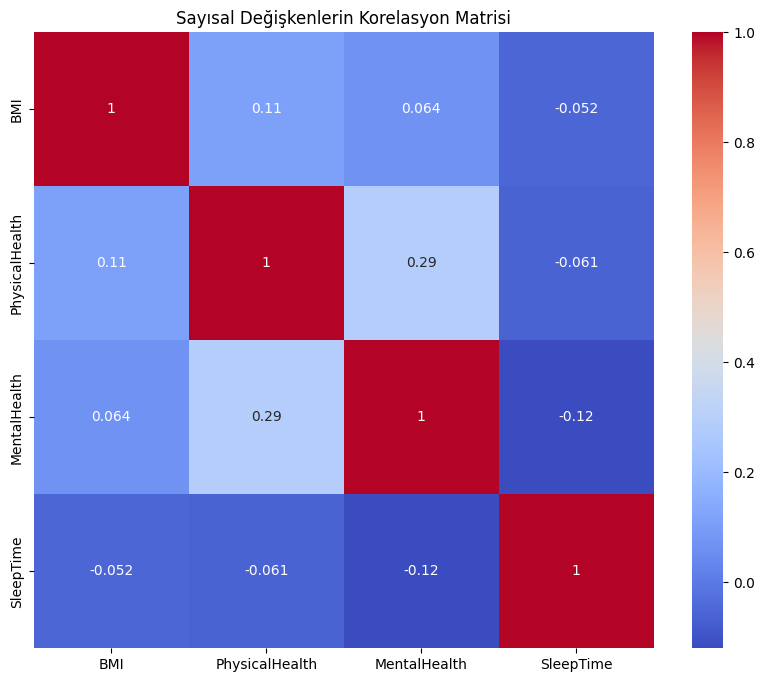

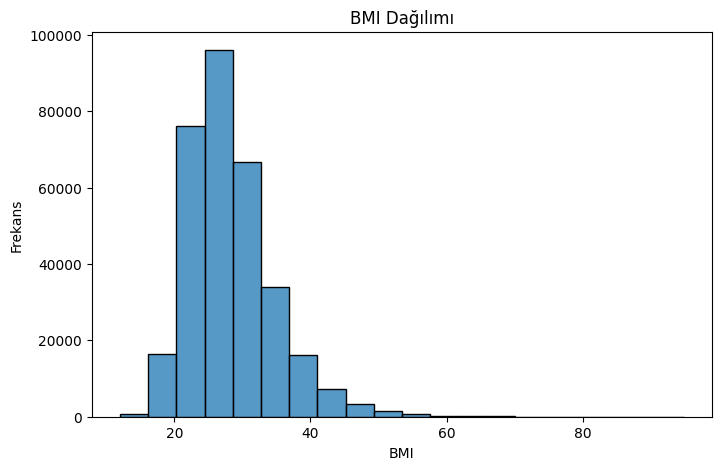

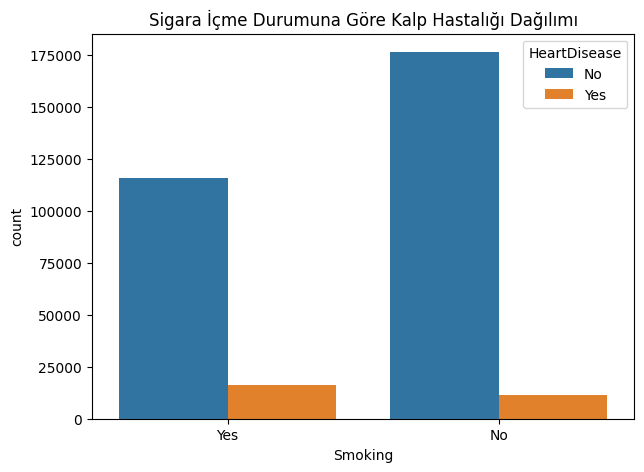

In [ ]:
df_pandas = df_spark.toPandas()

print(df_pandas.shape)

plt.figure(figsize=(10, 8))
sns.heatmap(df_pandas.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Sayısal Değişkenlerin Korelasyon Matrisi")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df_pandas['BMI'], bins=20)
plt.title("BMI Dağılımı")
plt.xlabel("BMI")
plt.ylabel("Frekans")
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='Smoking', hue='HeartDisease', data=df_pandas)
plt.title("Sigara İçme Durumuna Göre Kalp Hastalığı Dağılımı")
plt.show()

### 4. Kategorik Değişkenler Arası İlişki Analizi (Cramer V)
Veri setindeki kategorik değişkenlerin birbirleriyle olan ilişki düzeylerini ve etki büyüklüklerini saptamak amacıyla Ki-Kare istatistiğine dayalı Cramer V yöntemi uygulanmıştır. Elde edilen ilişki katsayıları ısı haritası üzerinde görselleştirilmiştir.

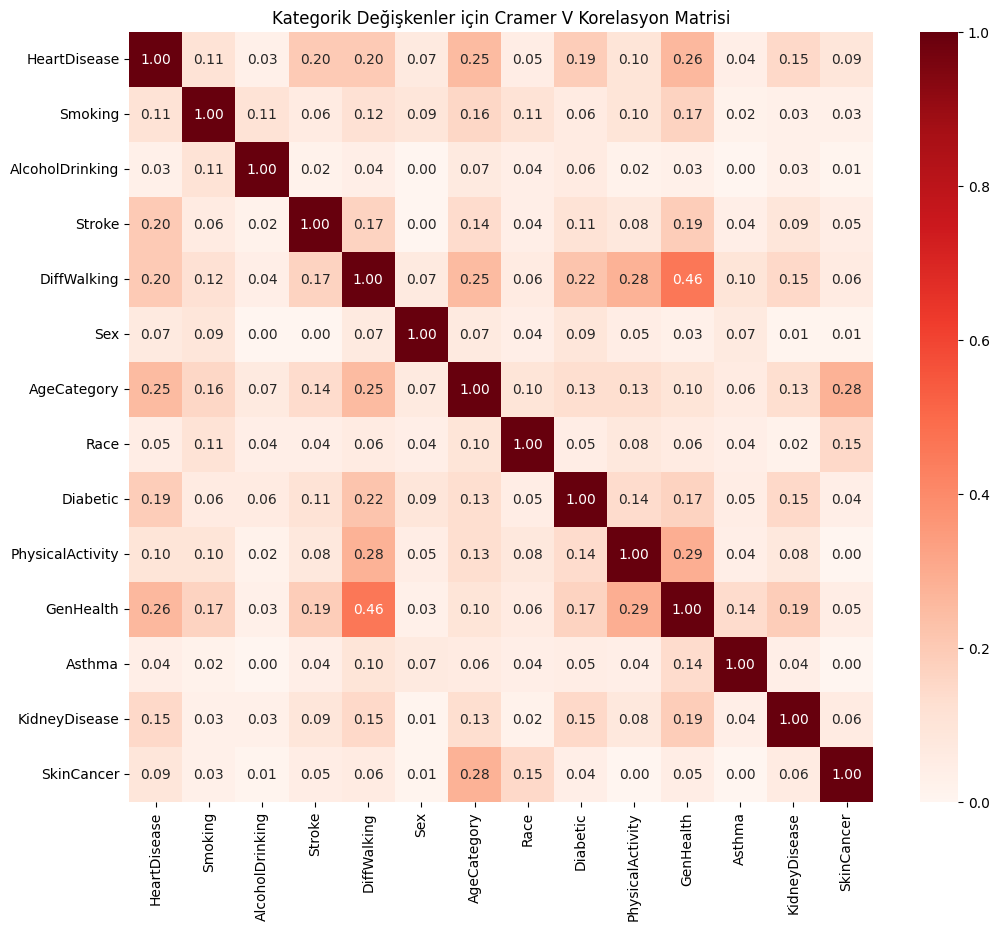

In [ ]:
def cramers_V(var1, var2):
  crosstab = np.array(pd.crosstab(var1, var2, rownames=None, colnames=None))
  stat = chi2_contingency(crosstab)[0]
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt(stat/(obs*mini))

categorical_cols = df_pandas.select_dtypes(include=['object']).columns.tolist()
rows = []

for var1 in categorical_cols:
  col = []
  for var2 in categorical_cols:
    cramers = cramers_V(df_pandas[var1], df_pandas[var2])
    col.append(round(cramers, 2))
  rows.append(col)

cramer_results = np.array(rows)
df_cramer = pd.DataFrame(cramer_results, columns=categorical_cols, index=categorical_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(df_cramer, annot=True, cmap='Reds', fmt='.2f')
plt.title("Kategorik Değişkenler için Cramer V Korelasyon Matrisi")
plt.show()

### 5. İstatistiksel Hipotez Testi (Ki-Kare Bağımsızlık Testi)
"Sigara Kullanımı" bağımsız değişkeni ile "Kalp Hastalığı" hedef değişkeni arasında istatistiksel olarak anlamlı bir bağımlılık olup olmadığı test edilmiştir. p < 0.05 anlamlılık düzeyinde Ki-Kare testi uygulanarak değişkenler arası ilişki istatistiksel olarak doğrulandı.

In [ ]:
contingency_table = pd.crosstab(df_pandas['Smoking'], df_pandas['HeartDisease'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square istatistiği: {chi2}")
print(f"P-Değeri: {p}")

if p < 0.05:
    print("Sonuç: Sigara içme ile kalp hastalığı arasındaki ilişki istatistiksel olarak anlamlıdır.")
else:
    print("Sonuç: İstatistiksel olarak anlamlı bir ilişki bulunamadı.")

Chi-Square istatistiği: 3713.0331469808216
P-Değeri: 0.0
Sonuç: Sigara içme ile kalp hastalığı arasındaki ilişki istatistiksel olarak anlamlıdır.


### 6. Veri Ön İşleme ve Eğitim-Test Kümesi Ayrımı
Makine öğrenmesi algoritmalarının işleyebileceği bir veri yapısı oluşturmak amacıyla kategorik değişkenlere Sayısal Kodlama işlemi uygulanmıştır Modelin genelleme yeteneğini ölçebilmek için veri seti %80 Eğitim ve %20 Test kümesi olarak ayrıştırıldı.

In [ ]:
df_model = df_pandas.copy()
le = LabelEncoder()

for col in df_model.columns:
      if df_model[col].dtype == 'object':
          df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('HeartDisease', axis=1)
y = df_model['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)

### 7. Makine Öğrenmesi Modellerinin Eğitimi ve Performans Kıyaslaması
Kalp hastalığı tahmininde en yüksek başarıyı sağlayan algoritmayı belirlemek üzere Decision Tree, Random Forest ve Gradient Boosting modelleri eğitilmiştir Modellerin aşırı öğrenme riskini değerlendirmek için eğitim ve test doğruluk skorları karşılaştırmalı olarak analiz edilmiştir.

               Model  Eğitim Doğruluğu  Test Doğruluğu
2  Gradient Boosting          0.916017        0.916353
1      Random Forest          0.996115        0.906565
0      Decision Tree          0.996873        0.867415


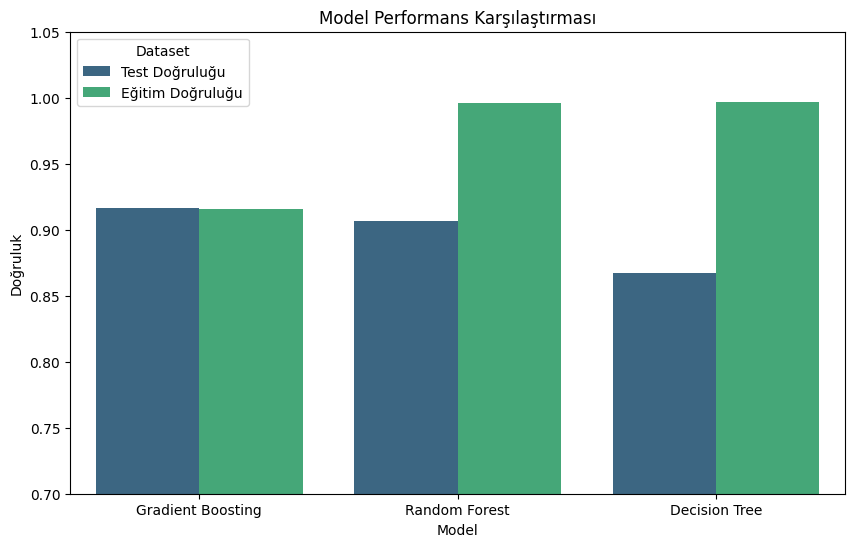

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=26),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=26),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=26)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Eğitim Doğruluğu": train_acc,
        "Test Doğruluğu": test_acc
    })

df_results = pd.DataFrame(results).sort_values(by="Test Doğruluğu", ascending=False)
print(df_results)

df_melted = df_results.melt(id_vars="Model", value_vars=["Test Doğruluğu", "Eğitim Doğruluğu"], var_name="Dataset", value_name="Doğruluk")

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Doğruluk", hue="Dataset", data=df_melted, palette="viridis")
plt.title("Model Performans Karşılaştırması")
plt.ylim(0.7, 1.05)
plt.ylabel("Doğruluk")
plt.show()

### 8. Final Model Değerlendirmesi ve Öznitelik Önem Düzeyleri
Yapılan kıyaslamalar sonucunda en dengeli ve yüksek performansı gösteren Gradient Boosting kullanılacak model olarak seçilmiştir. Modelin sınıflandırma başarısı detaylı olarak raporlanmış ve tahmin sürecinde en etkili olan risk faktörleri önem düzeylerine göre sıralanmıştır.

Son Model: Gradient Boosting Classifier
Test Doğruluğu: 0.9163526634250067
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     58539
           1       0.55      0.07      0.12      5420

    accuracy                           0.92     63959
   macro avg       0.74      0.53      0.54     63959
weighted avg       0.89      0.92      0.89     63959



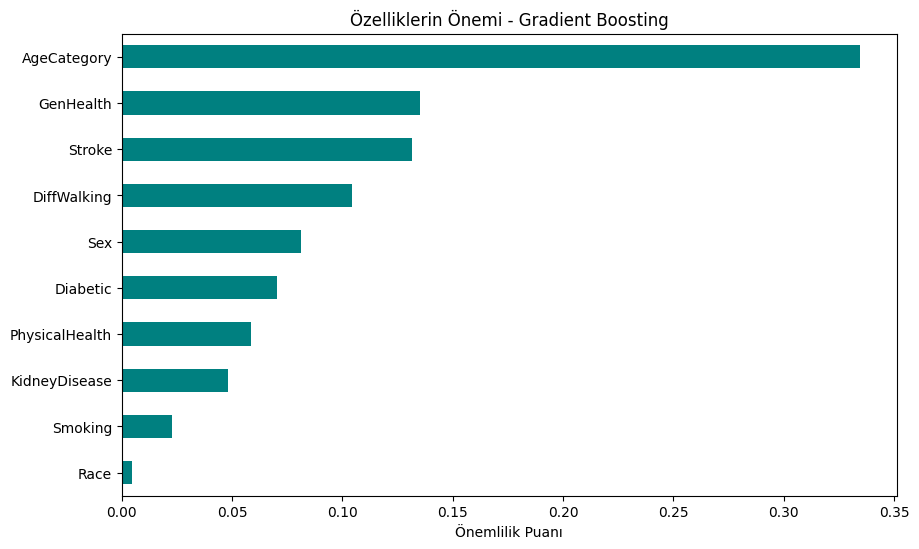

In [ ]:
final_model = GradientBoostingClassifier(n_estimators=50, random_state=26)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Son Model: Gradient Boosting Classifier")
print("Test Doğruluğu:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

feature_importance = pd.Series(final_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
feature_importance.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Özelliklerin Önemi - Gradient Boosting")
plt.xlabel("Önemlilik Puanı")
plt.show()

### 9. Senaryo Bazlı Tahminleme ve Model Tutarlılık Testi
Geliştirilen modelin tıbbi literatür ve klinik beklentilerle uyumluluğunu test etmek amacıyla düşük orta ve yüksek risk profillerini temsil eden yapay senaryolar oluşturulup modelin bu profiller için ürettiği hastalık olasılıkları hesaplanarak modelin güvenilirliği sınanmıştır.

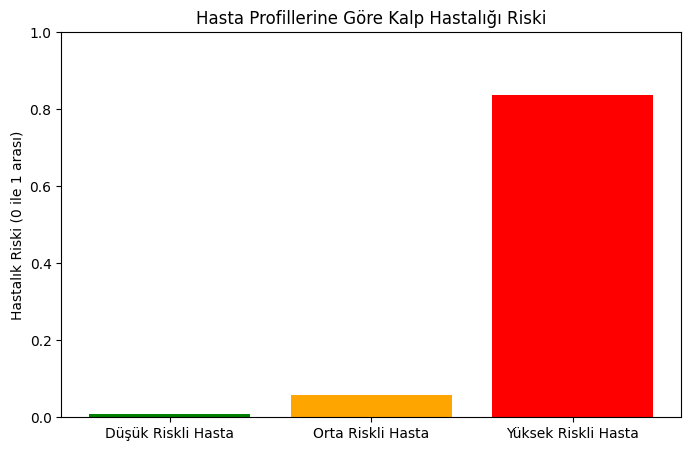

Düşük Riskli Hasta için Risk Oranı: 0.87
Orta Riskli Hasta için Risk Oranı: 5.68
Yüksek Riskli Hasta için Risk Oranı: 83.78


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

veri = df_pandas.copy()

kodlayicilar = {}

sutunlar = veri.select_dtypes(include=['object']).columns

for kolon in sutunlar:
    kodlayici = LabelEncoder()
    veri[kolon] = kodlayici.fit_transform(veri[kolon])
    kodlayicilar[kolon] = kodlayici

X = veri.drop('HeartDisease', axis=1)
y = veri['HeartDisease']

model = GradientBoostingClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

yeni_hastalar = pd.DataFrame([
    {
        'BMI': 22.5, 'Smoking': 'No', 'AlcoholDrinking': 'No', 'Stroke': 'No',
        'PhysicalHealth': 0, 'MentalHealth': 0, 'DiffWalking': 'No', 'Sex': 'Female',
        'AgeCategory': '25-29', 'Race': 'White', 'Diabetic': 'No',
        'PhysicalActivity': 'Yes', 'GenHealth': 'Excellent', 'SleepTime': 8,
        'Asthma': 'No', 'KidneyDisease': 'No', 'SkinCancer': 'No'
    },
    {
        'BMI': 28.0, 'Smoking': 'Yes', 'AlcoholDrinking': 'No', 'Stroke': 'No',
        'PhysicalHealth': 2, 'MentalHealth': 5, 'DiffWalking': 'No', 'Sex': 'Male',
        'AgeCategory': '50-54', 'Race': 'White', 'Diabetic': 'No',
        'PhysicalActivity': 'Yes', 'GenHealth': 'Good', 'SleepTime': 6,
        'Asthma': 'No', 'KidneyDisease': 'No', 'SkinCancer': 'No'
    },
    {
        'BMI': 35.5, 'Smoking': 'Yes', 'AlcoholDrinking': 'No', 'Stroke': 'Yes',
        'PhysicalHealth': 15, 'MentalHealth': 0, 'DiffWalking': 'Yes', 'Sex': 'Male',
        'AgeCategory': '70-74', 'Race': 'White', 'Diabetic': 'Yes',
        'PhysicalActivity': 'No', 'GenHealth': 'Poor', 'SleepTime': 5,
        'Asthma': 'Yes', 'KidneyDisease': 'Yes', 'SkinCancer': 'Yes'
    }
])

hasta_profilleri = ["Düşük Riskli Hasta", "Orta Riskli Hasta", "Yüksek Riskli Hasta"]

tahmin_verisi = yeni_hastalar.copy()

for kolon in sutunlar:
    if kolon in tahmin_verisi.columns:
        donusturucu = kodlayicilar[kolon]
        tahmin_verisi[kolon] = donusturucu.transform(tahmin_verisi[kolon])

tahminler = model.predict_proba(tahmin_verisi)
hasta_olma_ihtimalleri = tahminler[:, 1]

plt.figure(figsize=(8, 5))
renkler = ['green', 'orange', 'red']
plt.bar(hasta_profilleri, hasta_olma_ihtimalleri, color=renkler)

plt.title('Hasta Profillerine Göre Kalp Hastalığı Riski')
plt.ylabel('Hastalık Riski (0 ile 1 arası)')
plt.ylim(0, 1)
plt.show()

for i in range(3):
    isim = hasta_profilleri[i]
    risk = hasta_olma_ihtimalleri[i]
    print(isim, "için Risk Oranı:", round(risk * 100, 2))